In [1]:
import os
import rasterio
import rioxarray as rxr
from scipy.stats import linregress
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/WY23/20230405 - Copy/"
model_dir = os.path.join(dir, "outputs/task1/rasters")
lidar_dir = os.path.join(dir, "lidar")



In [3]:
EB_mcs_path = os.path.join(model_dir,"HMS_Energy_Balance_lidar_resample.tif")
TI_mcs_path = os.path.join(model_dir,"HMS_Temperature_Index_lidar_resample.tif")
iSno_mcs_path = os.path.join(model_dir,"iSnobal_lidar_resample.tif")
SM_mcs_path = os.path.join(model_dir,"SnowModel_lidar_resample.tif")
#LiDAR_path = Path(os.path.join(lidar_dir,"lidar_20230405.tif"))

LiDAR_path = os.path.join(lidar_dir,"lidar_20230405.tif")


In [23]:
#Create mask of all rasters
models = [EB_mcs_path, TI_mcs_path, iSno_mcs_path, SM_mcs_path, LiDAR_path]

for raster in models:
    with rasterio.open(raster) as src:
        data = src.read(1)
        masked_data = np.ma.masked_invalid(data)
        print(os.path.basename(raster))
        print(src.nodata)
        print(masked_data.min(), masked_data.max())


HMS_Energy_Balance_lidar_resample.tif
-9999.0
1.3028333 1.8882242
HMS_Temperature_Index_lidar_resample.tif
-9999.0
1.7265093 2.6384327
iSnobal_lidar_resample.tif
-9999.0
0.39703324 3.3208447
SnowModel_lidar_resample.tif
-9999.0
0.4259279 3.3463948
lidar_20230405.tif
-9999.0
-9999.0 6.633045


In [4]:
# Open rasters
lidar = rxr.open_rasterio(LiDAR_path, masked=True).squeeze()
lidar = xr.where(lidar <= 4.5, lidar, np.nan)
EB_mcs = rxr.open_rasterio(EB_mcs_path, masked=True).squeeze()
TI_mcs = rxr.open_rasterio(TI_mcs_path, masked=True).squeeze()
iSno_mcs = rxr.open_rasterio(iSno_mcs_path, masked=True).squeeze()
SM_mcs = rxr.open_rasterio(SM_mcs_path, masked=True).squeeze()

models = {"HMS-Energy Balance": EB_mcs, "HMS-Temperature Index": TI_mcs, "iSnobal": iSno_mcs,"SnowModel": SM_mcs}


In [49]:
for name, model_data in models.items():
# Flatten
        x = lidar.values.flatten()
        y = model_data.values.flatten()
    
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        print(name)
        print(linregress(x_clean, y_clean))


Energy Balance
LinregressResult(slope=0.17265377560214276, intercept=1.2429261221531342, rvalue=0.6893042926424082, pvalue=0.0, stderr=0.0034360732147864755, intercept_stderr=0.009510325147611187)
Temperature Index
LinregressResult(slope=0.25557618620137235, intercept=1.6973734345493585, rvalue=0.6831256391562456, pvalue=0.0, stderr=0.00517365375761733, intercept_stderr=0.014319581208096812)
iSnobal
LinregressResult(slope=0.8824589632738516, intercept=0.08136186518493105, rvalue=0.8716070499041947, pvalue=0.0, stderr=0.00939782713524977, intercept_stderr=0.026011201202772605)
SnowModel
LinregressResult(slope=0.8527069295749012, intercept=-0.034005245121424554, rvalue=0.8104182983280676, pvalue=0.0, stderr=0.011799849276727939, intercept_stderr=0.03280965111677063)


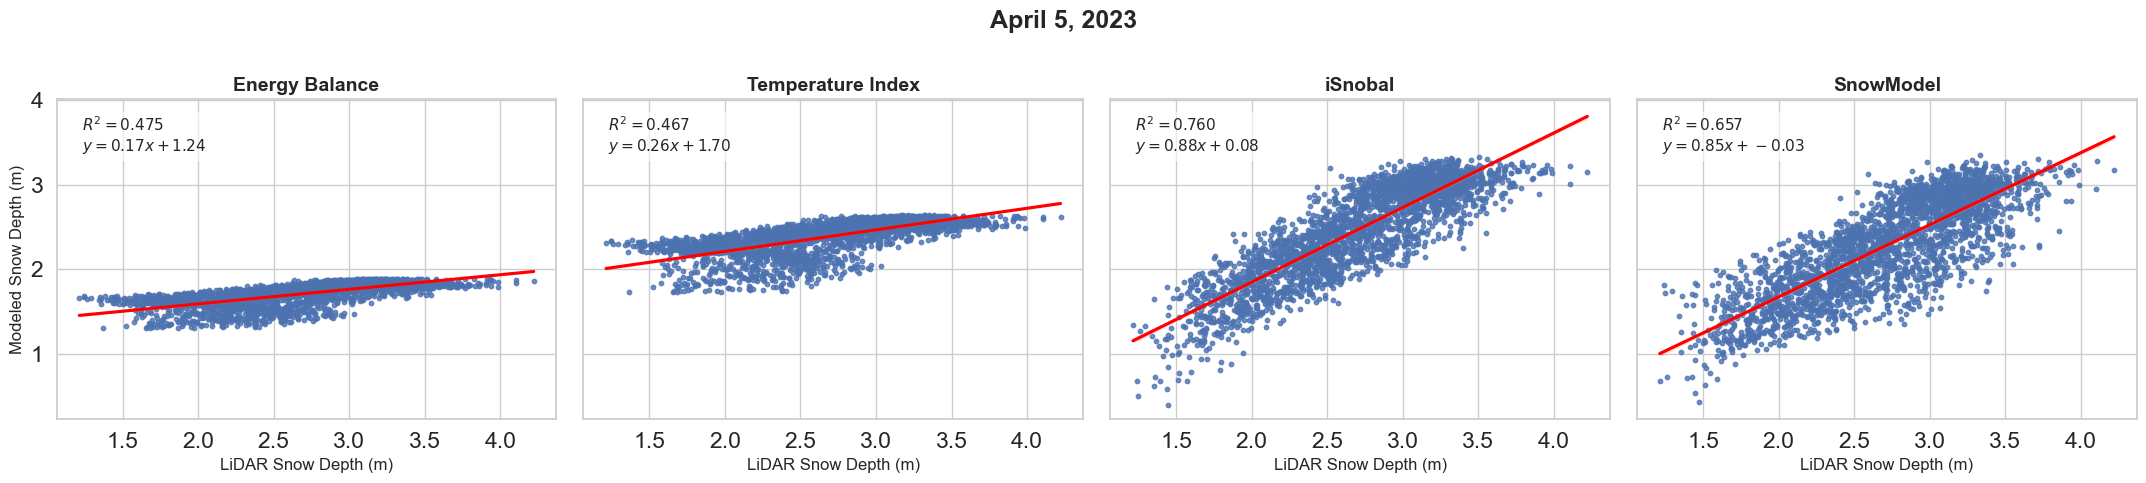

In [66]:

# --- Create the figure and subplots ---
# We have 4 models, so we create 4 subplots (1 row, 4 columns)
# I've increased the figsize for better readability

sns.set_style('whitegrid')

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
fig.suptitle('April 5, 2023', fontsize=18, fontweight='bold')

# --- Loop through each model to create a subplot ---
# We use enumerate to get an index 'i' for selecting the subplot
for i, (name, model_data) in enumerate(models.items()):
    
    # 1. Flatten and clean data (your existing code)
    # Ensure you are using the cleaned data for plotting!
    x = lidar.values.flatten()
    y = model_data.values.flatten()
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]

    # Select the correct subplot for the current model
    ax = axs[i]
    
    # 2. Create the regression plot on the correct subplot
    # Use the cleaned data (x_clean, y_clean) for the plot
    sns.regplot(x=x_clean, y=y_clean, ax=ax,
                scatter_kws={'alpha': 0.8, 's': 10}, # Make points transparent to see density
                line_kws={'color': 'red'})          # Make regression line stand out
                
    # 3. Calculate statistics to display on the plot
    slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
    r_squared = r_value**2
    
    # 4. Add title and labels
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

    # 5. Add a text box with the R² and regression equation
    # The text is placed using relative coordinates (0.05, 0.95) -> 5% from left, 95% from top
    stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
    ax.text(0.05, 0.95, stats_text, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

# --- Final Figure-Level Adjustments ---
# Add a single, shared y-label for the entire figure
axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)

# Improve layout to prevent titles/labels from overlapping
plt.tight_layout()

# Display the final plot
plt.show()



In [5]:
##Differenced Maps

EB_diff_path = os.path.join(model_dir,"HMS_Energy_Balance_lidar_diff.tif")
TI_diff_path = os.path.join(model_dir,"HMS_Temperature_Index_lidar_diff.tif")
iSno_diff_path = os.path.join(model_dir,"iSnobal_lidar_diff.tif")
SM_diff_path = os.path.join(model_dir,"SnowModel_lidar_diff.tif")

EB_diff = rxr.open_rasterio(EB_diff_path, masked=True).squeeze()
TI_diff = rxr.open_rasterio(TI_diff_path, masked=True).squeeze()
iSno_diff = rxr.open_rasterio(iSno_diff_path, masked=True).squeeze()
SM_diff = rxr.open_rasterio(SM_diff_path, masked=True).squeeze()

models = {"HMS-Energy Balance": EB_diff, "HMS-Temperature Index": TI_diff, "iSnobal": iSno_diff,"SnowModel": SM_diff}



In [6]:
for model_name, model_data in models.items():
        print(model_name)        
        min_val = model_data.min().item()
        max_val = model_data.max().item()
        print(min_val, max_val)



Energy Balance
-0.44947683811187744 4.845304489135742
Temperature Index
-1.1006909608840942 4.152706146240234
iSnobal
-0.6743927001953125 3.483280658721924
SnowModel
-0.5716476440429688 3.6556289196014404


In [9]:
## one pixel with noise in the LiDAR dataset is causing an issues in following cells, so I am going to remove the high noise by filtering lidar diffs for now
## temporary fix, I should potentially return to the lidar

filtered_models = {}

for name, data in models.items():
    filtered_data_array = data.where(data <= 3.4, drop=False)
    filtered_models[name] = filtered_data_array

print(filtered_models)

{'Energy Balance': <xarray.DataArray (y: 84, x: 79)> Size: 27kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    band         int32 4B 1
  * x            (x) float64 632B 6.016e+05 6.017e+05 ... 6.093e+05 6.094e+05
  * y            (y) float64 672B 4.871e+06 4.871e+06 ... 4.863e+06 4.863e+06
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0, 'Temperature Index': <xarray.DataArray (y: 84, x: 79)> Size: 27kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, na

In [10]:
global_min, global_max = [], []
for data in filtered_models.values():
    global_min.append(data.min().item())
    global_max.append(data.max().item())
    
print(global_min, global_max)

v_abs = [min(global_min), max(global_max)]
v_abs

[-0.44947683811187744, -1.1006909608840942, -0.6743927001953125, -0.5716476440429688] [2.3589956760406494, 1.6074657440185547, 1.1461632251739502, 1.636482834815979]


[-1.1006909608840942, 2.3589956760406494]

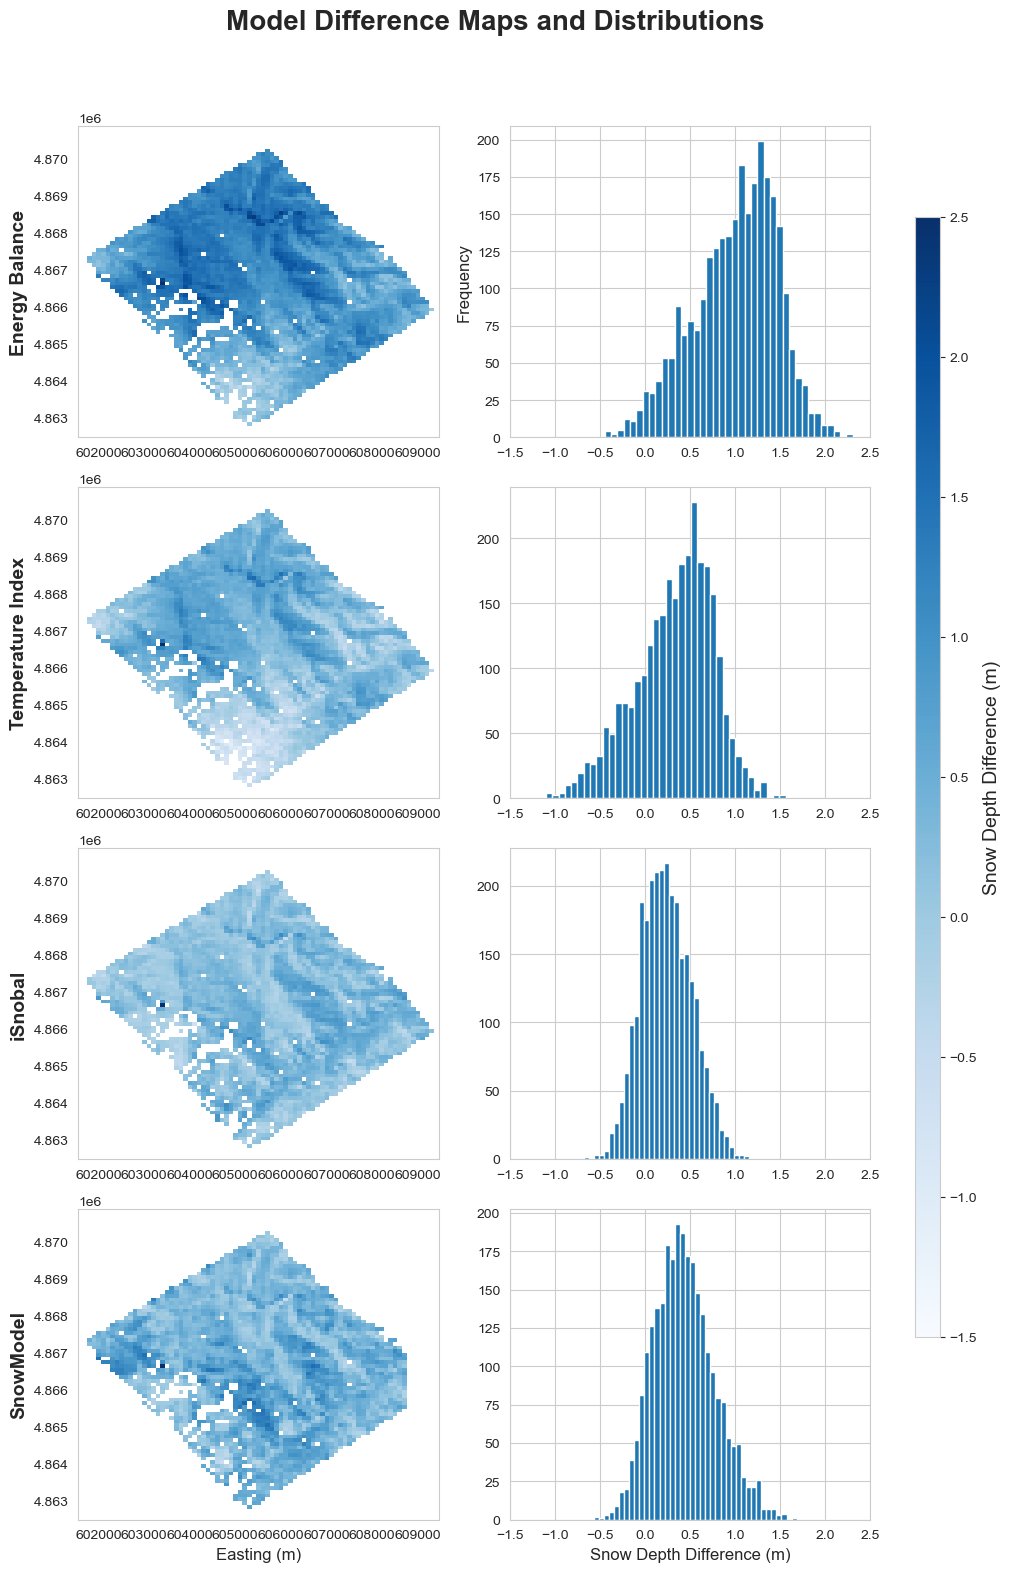

In [23]:
min_fig = -1.5
max_fig = 2.5

fig, axs = plt.subplots(
    nrows=4, 
    ncols=2, 
    figsize=(10, 16), 
    # Link x-axes within columns, making coordinates and hist bins align
    sharex='col' 
)

fig.suptitle('Model Difference Maps and Distributions', fontsize=20, fontweight='bold')

# --- 3. Loop through each model and plot on the correct row ---
for i, (name, data) in enumerate(models.items()):
    # Define the axes for the current row
    ax_raster = axs[i, 0]
    ax_hist = axs[i, 1]
    
    # --- Plot 1: Raster Map (Left Column) ---
    im = data.plot(ax=ax_raster, cmap='Blues', vmin=min_fig, vmax=max_fig, add_colorbar=False)
    
    # Use the y-label of the raster plot as a row title
    ax_raster.set_title("") 
    ax_raster.set_ylabel(name, fontsize=14, fontweight='bold')
    ax_raster.set_xlabel("")
    #ax_raster.set_xlabel('') # We'll set the x-label only on the last plot

    # --- Plot 2: Histogram (Right Column) ---
    hist_data = data.values.flatten()
    hist_data = hist_data[~np.isnan(hist_data)]
    ax_hist.hist(hist_data, bins=75) #, color='grey' , edgecolor='white')
    ax_hist.set_xlim(min_fig, max_fig) # Apply shared x-axis limits
    
    # Add a vertical line at zero to show the center of the differences
    #ax_hist.axvline(0, color='red', linestyle='--', linewidth=1.5)
    
# --- 4. Finalize titles and labels for columns and axes ---
# Set titles for the two columns on the topmost plots
#axs[0, 0].set_title('Spatial Difference Map', fontsize=16)
#axs[0, 1].set_title('Distribution of Differences', fontsize=16)
for ax in axs.flat:
    ax.tick_params(axis='x', labelbottom=True)
# Set shared axis labels on the bottom-most plots
axs[3, 0].set_xlabel('Easting (m)', fontsize=12)
axs[3, 1].set_xlabel('Snow Depth Difference (m)', fontsize=12)

# Set a y-label for the histograms
axs[0, 1].set_ylabel('Frequency', fontsize=12)


# --- 5. Add a single, shared colorbar ---
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space

# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth Difference (m)', fontsize=14)

plt.show()


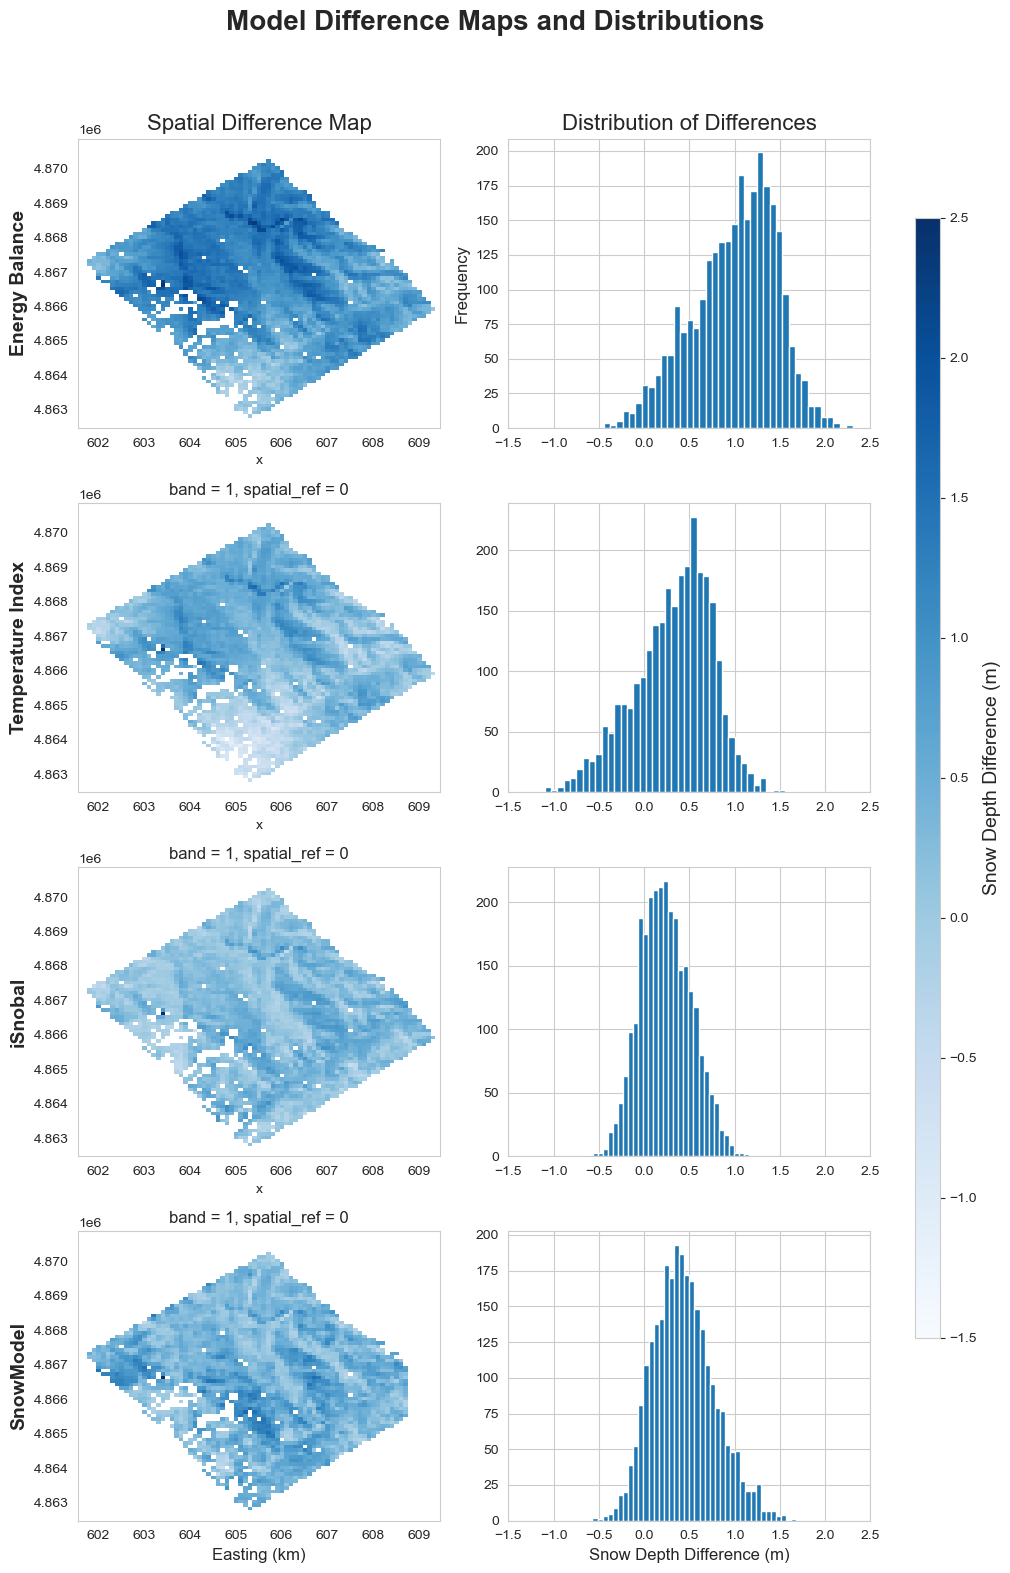

In [20]:
import matplotlib.pyplot as plt
import numpy as np
# 1. IMPORT THE FORMATTER
from matplotlib.ticker import FuncFormatter

# Assuming 'models' and other variables are loaded

min_fig = -1.5
max_fig = 2.5

# 2. DEFINE THE FUNCTION TO FORMAT THE TICK LABELS
# This function will be called for each tick on the x-axis
def kilo_formatter(x, pos):
    """
    Formats the tick value by dividing by 1000 and returning an integer string.
    x: the original tick value (e.g., 602000)
    pos: the position of the tick (we don't need it, but the function requires it)
    """
    return f'{int(x / 1000)}'


fig, axs = plt.subplots(
    nrows=4, 
    ncols=2, 
    figsize=(10, 16), 
    sharex='col'
)

fig.suptitle('Model Difference Maps and Distributions', fontsize=20, fontweight='bold')

# --- Loop through each model and plot ---
for i, (name, data) in enumerate(models.items()):
    ax_raster = axs[i, 0]
    ax_hist = axs[i, 1]
    
    # --- Plot 1: Raster Map ---
    im = data.plot(ax=ax_raster, cmap='Blues', vmin=min_fig, vmax=max_fig, add_colorbar=False)
    
    # 3. APPLY THE CUSTOM FORMATTER TO THE RASTER'S X-AXIS
    ax_raster.xaxis.set_major_formatter(FuncFormatter(kilo_formatter))
    
    ax_raster.set_ylabel(name, fontsize=14, fontweight='bold')

    # --- Plot 2: Histogram ---
    hist_data = data.values.flatten()
    hist_data = hist_data[~np.isnan(hist_data)]
    ax_hist.hist(hist_data, bins=75)
    ax_hist.set_xlim(min_fig, max_fig)
    
# --- Finalize titles and labels ---
axs[0, 0].set_title('Spatial Difference Map', fontsize=16)
axs[0, 1].set_title('Distribution of Differences', fontsize=16)

# Turn on all tick labels
for ax in axs.flat:
    ax.tick_params(axis='x', labelbottom=True)

# 4. UPDATE THE X-AXIS LABEL TO REFLECT THE NEW UNITS
axs[3, 0].set_xlabel('Easting (km)', fontsize=12) # Changed from 'm' to 'km' or (x1000 m)
axs[3, 1].set_xlabel('Snow Depth Difference (m)', fontsize=12)

axs[0, 1].set_ylabel('Frequency', fontsize=12)

# --- Add a single, shared colorbar ---
fig.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth Difference (m)', fontsize=14)

plt.show()
